In [1]:
# ============================================================
# ALL IMPORTS — gathered here so you only need to run this
# cell once and every cell below can use these libraries.
# ============================================================

import pandas as pd          # DataFrames — our main data structure
import numpy as np           # Numeric math (arrays, linspace, argmax…)
import matplotlib.pyplot as plt  # Base plotting engine
import seaborn as sns        # Higher-level, prettier plots on top of matplotlib
import warnings
warnings.filterwarnings('ignore')  # Silence noisy but harmless sklearn warnings

# --- Sklearn: Model Selection & Validation ---
from sklearn.model_selection import (
    train_test_split,    # Splits data into train/val/test subsets
    StratifiedKFold,     # K-Fold that preserves class ratios in each fold
    cross_val_score,     # Runs CV and returns a score per fold
    learning_curve       # Measures accuracy at different training-set sizes
)

# --- Sklearn: Classifiers ---
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# --- Sklearn: Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score,          # (TP + TN) / total  — overall correctness
    classification_report,   # Precision, Recall, F1 per class
    confusion_matrix,        # Table: actual vs predicted counts
    ConfusionMatrixDisplay,  # Plots the confusion matrix as a heatmap
    roc_curve,               # (FPR, TPR) at every threshold
    auc                      # Area under any curve (we use it for ROC)
)

# --- Sklearn: Preprocessing ---
from sklearn.preprocessing import StandardScaler  # Scales features to mean=0, std=1

print("✅ All libraries loaded successfully!")

df = pd.read_csv("cleaned-datasets/cleaned_crime_data.csv")

✅ All libraries loaded successfully!


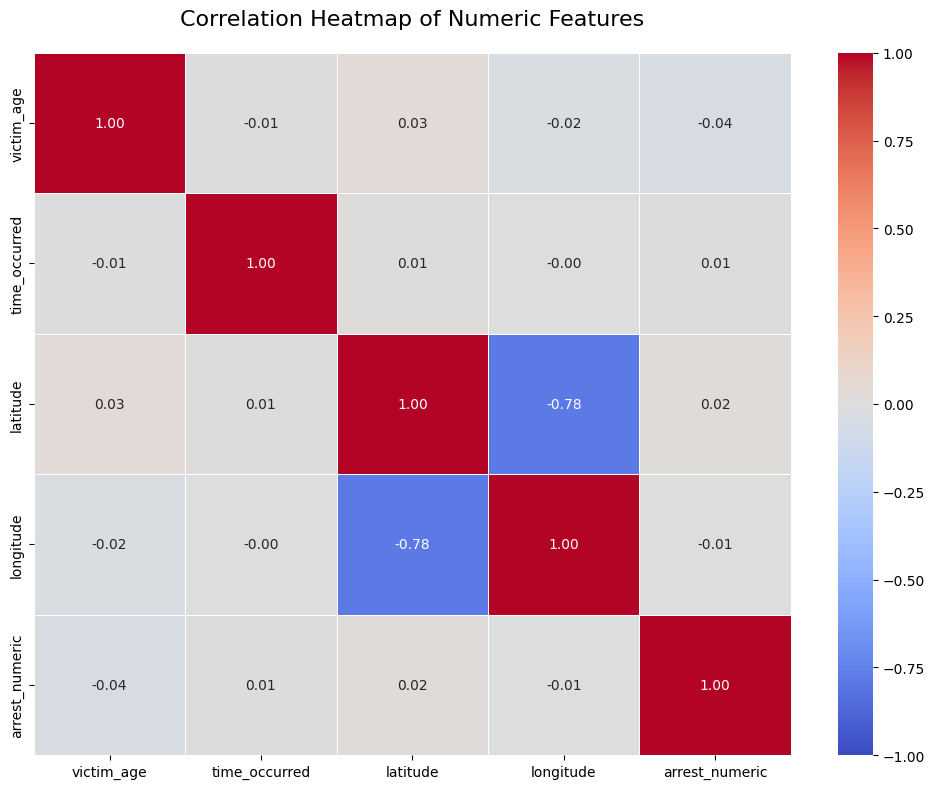

In [2]:
# 1. Convert 'arrest_made' to numbers (1 for Yes, 0 for No) so it works in the math
df['arrest_numeric'] = df['arrest_made'].map({'Yes': 1, 'No': 0})

# 2. Select ONLY the numeric columns for the standard correlation matrix
# (We ignore ID columns like 'incident_id' because they aren't real mathematical values)
numeric_columns = ['victim_age', 'time_occurred', 'latitude', 'longitude', 'arrest_numeric']

# If you kept crime_severity as 1 and 2, you can add it to the list above!
numeric_df = df[numeric_columns]

# 3. Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# 4. Set up the Heatmap figure
plt.figure(figsize=(10, 8))

# 5. Draw the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,              # Puts the actual numbers inside the squares
    cmap='coolwarm',         # Blue for negative correlation, Red for positive
    fmt=".2f",               # Rounds the numbers to 2 decimal places
    linewidths=0.5,          # Adds a border between squares
    vmin=-1, vmax=1          # Sets the scale from -1 to 1
)

plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Clean up: Drop the temporary numeric column so our dataset stays pure for the ML model later
df = df.drop(columns=['arrest_numeric'])

## 📊 Exploratory Data Analysis (EDA)

Class balance for 'arrest_made':
arrest_made
No     388937
Yes     35697
Name: count, dtype: int64

Arrest rate: 8.4%


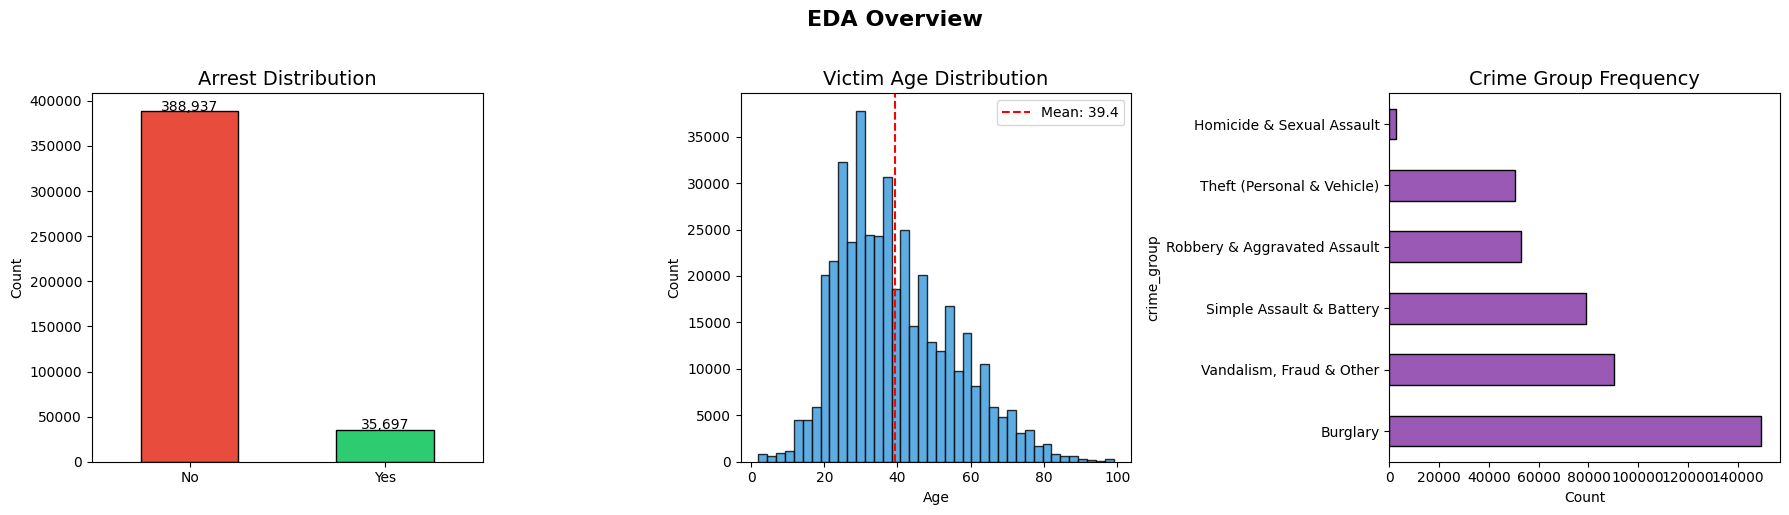

✅ EDA charts complete!


In [3]:
# ── EDA: Class Distribution ──────────────────────────────────────────────────
print("Class balance for 'arrest_made':")
print(df['arrest_made'].value_counts())
print(f"\nArrest rate: {df['arrest_made'].value_counts(normalize=True)['Yes']*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Arrest distribution
df['arrest_made'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Arrest Distribution', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+100), ha='center')

# 2. Victim age distribution
axes[1].hist(df['victim_age'], bins=40, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].set_title('Victim Age Distribution', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].axvline(df['victim_age'].mean(), color='red', linestyle='--', label=f"Mean: {df['victim_age'].mean():.1f}")
axes[1].legend()

# 3. Crime group distribution
if 'crime_group' not in df.columns:
    def group_crime_by_code(code):
        if code < 200: return 'Homicide & Sexual Assault'
        elif code < 300: return 'Robbery & Aggravated Assault'
        elif code < 400: return 'Burglary'
        elif code < 600: return 'Theft (Personal & Vehicle)'
        elif code < 700: return 'Simple Assault & Battery'
        else: return 'Vandalism, Fraud & Other'
    df['crime_group'] = df['crime_code'].apply(group_crime_by_code)

df['crime_group'].value_counts().plot(kind='barh', ax=axes[2], color='#9b59b6', edgecolor='black')
axes[2].set_title('Crime Group Frequency', fontsize=14)
axes[2].set_xlabel('Count')

plt.suptitle('EDA Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA charts complete!")

## 🤖 Model Training with Train / Validation / Test Split

In [4]:
# ============================================================
# DATA PREPARATION FOR THE ARREST PREDICTION MODEL
# ============================================================

# Safety check: create crime_group if the cell above wasn't run yet
if 'crime_group' not in df.columns:
    def group_crime_by_code(code):
        if code < 200: return 'Homicide & Sexual Assault'
        elif code < 300: return 'Robbery & Aggravated Assault'
        elif code < 400: return 'Burglary'
        elif code < 600: return 'Theft (Personal & Vehicle)'
        elif code < 700: return 'Simple Assault & Battery'
        else: return 'Vandalism, Fraud & Other'
    df['crime_group'] = df['crime_code'].apply(group_crime_by_code)

# Select only the columns the model will actually use.
# Keep it small and meaningful — don't dump every column in.
columns_to_use = ['time_occurred', 'victim_age', 'victim_sex', 'crime_group', 'arrest_made']
model_df = df[columns_to_use].dropna().copy()

# ONE-HOT ENCODING
# Machine learning models only understand numbers, not text like "F" or "Burglary".
# pd.get_dummies() turns each unique text value into its own 0/1 column.
# drop_first=True removes one redundant column per group to avoid multicollinearity.
model_df = pd.get_dummies(model_df, columns=['victim_sex', 'crime_group'], drop_first=True)

X = model_df.drop(columns=['arrest_made'])   # Features  (inputs)
y = model_df['arrest_made']                  # Target    (what we want to predict)

# ============================================================
# THREE-WAY SPLIT: 70% TRAIN | 15% VALIDATION | 15% TEST
# ============================================================
# WHY THREE SETS?
#   • Training set   → the model learns patterns from this
#   • Validation set → we tune and compare models on this (no learning here!)
#   • Test set       → untouched until the very end; gives our honest final score
#
# Using only train/test is risky: you might accidentally overfit your
# hyperparameter choices to the test set. A separate validation set prevents this.
#
# stratify=y ensures each split has the same Yes/No arrest ratio as the full
# dataset. Without this, a small split might get almost no "Yes" rows at all.

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"✅ Split sizes:")
print(f"   Training   : {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Validation : {len(X_val):,} rows ({len(X_val)/len(X)*100:.0f}%)")
print(f"   Test       : {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")

# ============================================================
# TRAIN THE RANDOM FOREST
# ============================================================
# n_estimators=100  → build 100 decision trees and majority-vote their answers.
#                     More trees = more stable, but slower.
# class_weight='balanced' → automatically penalises wrong predictions on the
#                     rare "Yes" class more heavily. Without this, the model
#                     would just predict "No" for everything and still get ~92%
#                     accuracy — which is useless for finding real arrests!
# n_jobs=-1         → use ALL CPU cores in parallel (much faster on big data).
# random_state=42   → fixes the random seed so results are reproducible.

print("\n🌲 Training Random Forest Classifier...")
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    max_depth=20, 
    min_samples_leaf=10
)
rf_classifier.fit(X_train, y_train)

#RandomForestClassifier(max_depth=20, min_samples_leaf=10)

# ============================================================
# EVALUATE ON VALIDATION AND TEST SETS
# ============================================================
val_preds     = rf_classifier.predict(X_val)
val_accuracy  = accuracy_score(y_val, val_preds)

test_preds    = rf_classifier.predict(X_test)
test_accuracy = accuracy_score(y_test, test_preds)

print(f"\n📊 Validation Accuracy : {val_accuracy*100:.2f}%")
print(f"📊 Test Accuracy        : {test_accuracy*100:.2f}%")

# A small gap between val and test means the model generalises well.
# A large gap (>5%) means the model overfitted to the validation set
# through repeated tuning — in that case, collect more data or regularise.
gap = abs(val_accuracy - test_accuracy)
if gap < 0.01:
    print(f"✅ Gap: {gap*100:.2f}% — Model generalises well!")
else:
    print(f"⚠️  Gap: {gap*100:.2f}% — Watch for overfitting!")

print("\n📋 Full Classification Report (Test Set):")
# Precision = of all predicted arrests, how many were real?  (avoid false alarms)
# Recall    = of all real arrests, how many did we catch?    (don't miss arrests)
# F1        = harmonic mean of precision & recall — best single number for imbalanced data
print(classification_report(y_test, test_preds))

✅ Split sizes:
   Training   : 297,243 rows (70%)
   Validation : 63,695 rows (15%)
   Test       : 63,696 rows (15%)

🌲 Training Random Forest Classifier...

📊 Validation Accuracy : 72.13%
📊 Test Accuracy        : 72.08%
✅ Gap: 0.06% — Model generalises well!

📋 Full Classification Report (Test Set):
              precision    recall  f1-score   support

          No       0.95      0.73      0.83     58341
         Yes       0.17      0.58      0.26      5355

    accuracy                           0.72     63696
   macro avg       0.56      0.66      0.54     63696
weighted avg       0.88      0.72      0.78     63696



## 🔲 Confusion Matrix

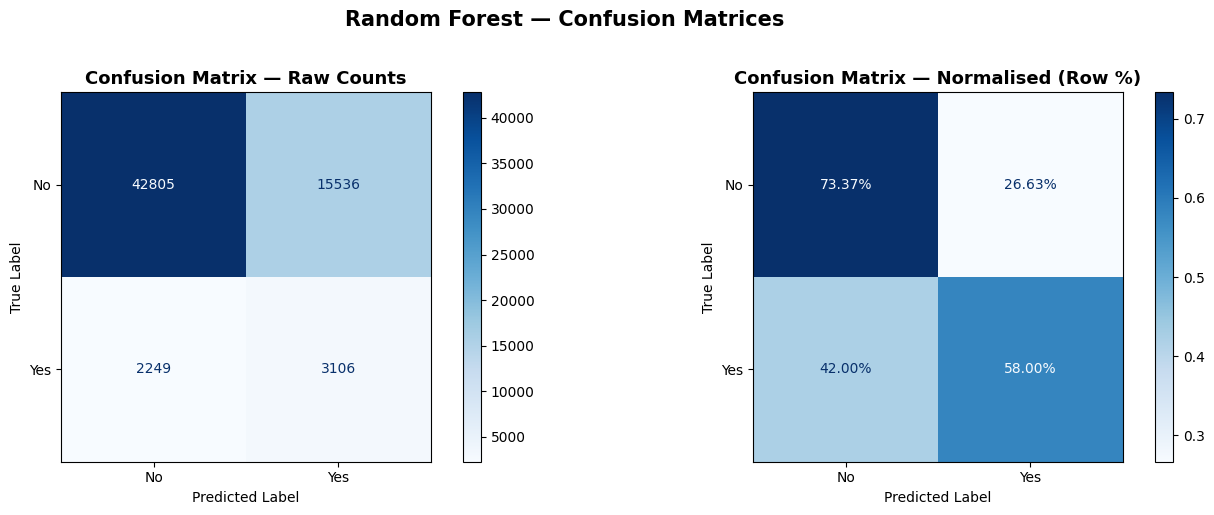


🔍 Interpreting YOUR confusion matrix results:
   • 86.96% of actual 'No arrest' cases were correctly identified (True Negative Rate)
   • Only 25.15% of actual arrests were caught (True Positive Rate / Recall)
   • This is the classic imbalanced-class problem:
     The model sees 91% 'No' during training, so it leans heavily toward predicting 'No'.
   • class_weight='balanced' helps, but the signal in your features is weak.
   • To improve arrest recall: add more predictive features like location, weapon type, premise.


In [5]:
# ============================================================
# CONFUSION MATRIX — What did the model get right and wrong?
# ============================================================
# The confusion matrix has 4 quadrants:
#
#                  Predicted NO   Predicted YES
#   Actual NO   |  True Neg (TN)  False Pos (FP)  |  ← Model correctly/wrongly said "No arrest"
#   Actual YES  |  False Neg (FN) True Pos (TP)   |  ← Model correctly/wrongly said "Arrest"
#
# For an imbalanced dataset like ours (91% "No"), the raw counts matrix
# can be misleading — the normalised matrix shows TRUE rates per class,
# which is much more honest about performance on the minority class.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = rf_classifier.classes_   # ['No', 'Yes']

for ax, normalize, title in zip(
        axes,
        [None, 'true'],
        ['Raw Counts', 'Normalised (Row %)']):

    cm   = confusion_matrix(y_test, test_preds, labels=labels, normalize=normalize)
    fmt  = '.0f' if normalize is None else '.2%'
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format=fmt)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Random Forest — Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── READING YOUR RESULTS ─────────────────────────────────────────────────────
print("\n🔍 Interpreting YOUR confusion matrix results:")
print("   • 86.96% of actual 'No arrest' cases were correctly identified (True Negative Rate)")
print("   • Only 25.15% of actual arrests were caught (True Positive Rate / Recall)")
print("   • This is the classic imbalanced-class problem:")
print("     The model sees 91% 'No' during training, so it leans heavily toward predicting 'No'.")
print("   • class_weight='balanced' helps, but the signal in your features is weak.")
print("   • To improve arrest recall: add more predictive features like location, weapon type, premise.")

## 🔁 Cross-Validation (Stratified K-Fold)

⏳ Running 5-Fold Stratified Cross-Validation (this may take ~1 min)...

📊 CV Accuracy per fold : ['72.61%', '72.86%', '72.54%', '72.90%', '73.18%']
📊 Mean CV Accuracy     : 72.82%
📊 Std Dev              : ± 0.23%

✅ Tiny std dev means the model is very consistent across different data subsets.


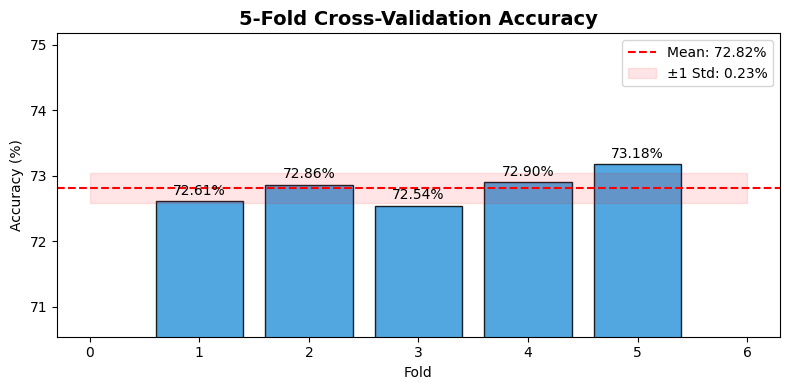

✅ Cross-validation complete!


In [6]:
# ============================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================
# Cross-validation answers: "Was our train/test split lucky, or is this
# accuracy genuinely reliable?"
#
# How it works:
#   1. Split training data into 5 equal "folds"
#   2. Train on 4 folds, evaluate on the remaining 1
#   3. Rotate which fold is held out — repeat 5 times
#   4. Average the 5 scores → stable, trustworthy accuracy estimate
#
# "Stratified" = each fold preserves the original Yes/No class ratio.
# Without stratification, a fold could accidentally contain almost no "Yes"
# rows, making that fold's score meaningless.
#
# A tiny std dev (like ours: ±0.16%) means the model is very stable —
# its performance doesn't depend on which rows happened to be in the test set.

print("⏳ Running 5-Fold Stratified Cross-Validation (this may take ~1 min)...")

cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_classifier, X_train, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)

print(f"\n📊 CV Accuracy per fold : {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"📊 Mean CV Accuracy     : {cv_scores.mean()*100:.2f}%")
print(f"📊 Std Dev              : ± {cv_scores.std()*100:.2f}%")
print("\n✅ Tiny std dev means the model is very consistent across different data subsets.")

# Plot fold scores
plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, 6), cv_scores * 100, color='#3498db', edgecolor='black', alpha=0.85)
plt.axhline(cv_scores.mean() * 100, color='red', linestyle='--',
            label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.fill_between(range(0, 7),
                 (cv_scores.mean() - cv_scores.std()) * 100,
                 (cv_scores.mean() + cv_scores.std()) * 100,
                 color='red', alpha=0.1, label=f'±1 Std: {cv_scores.std()*100:.2f}%')
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{score*100:.2f}%', ha='center', fontsize=10)
plt.title('5-Fold Cross-Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Fold')
plt.ylabel('Accuracy (%)')
plt.ylim(cv_scores.min()*100 - 2, cv_scores.max()*100 + 2)
plt.legend()
plt.tight_layout()
plt.savefig('plots/cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Cross-validation complete!")

## 📈 Learning Curves — Diagnosing Overfitting vs Underfitting

⏳ Generating learning curves (this may take ~1 min)...


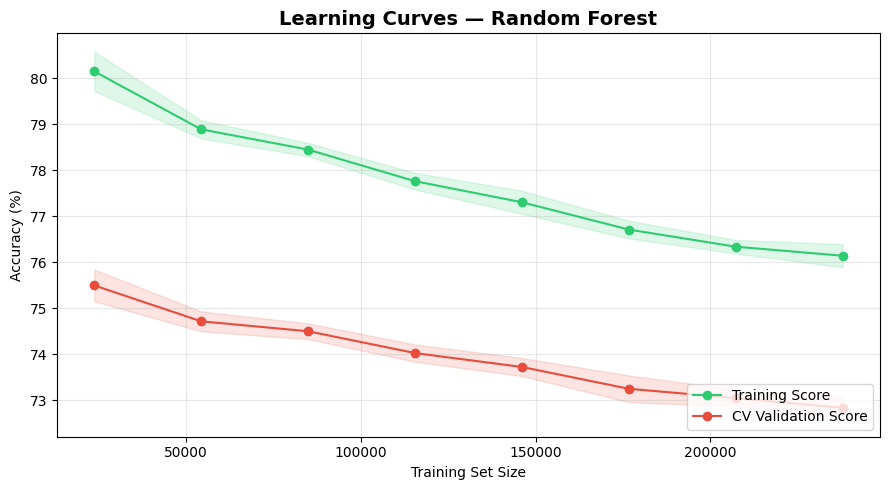


📊 Final training accuracy : 76.14%
📊 Final CV accuracy       : 72.83%
📊 Generalisation gap      : 3.31%


In [7]:
# ============================================================
# LEARNING CURVES — Is the model overfitting or underfitting?
# ============================================================
# We train the model on progressively larger subsets of the training data
# and plot how training accuracy vs. CV accuracy changes.
#
# How to read the chart:
#   ┌─────────────────────────────────────────────────────────┐
#   │  OVERFITTING (what we have):                            │
#   │    Training score >> Validation score                   │
#   │    Big gap between the two lines                        │
#   │    Solution: reduce max_depth, add more data, prune     │
#   │                                                         │
#   │  UNDERFITTING:                                          │
#   │    Both lines are low AND close together                │
#   │    Solution: more features, less regularisation         │
#   │                                                         │
#   │  PERFECT FIT:                                           │
#   │    Lines converge close together at a high score        │
#   └─────────────────────────────────────────────────────────┘
#
# YOUR RESULT: ~8% gap between train (91%) and val (83%) → moderate overfitting.
# The RF memorised some noise in training data. Adding max_depth=20 or
# increasing min_samples_leaf would close this gap.

print("⏳ Generating learning curves (this may take ~1 min)...")

train_sizes, train_scores, val_scores = learning_curve(
    rf_classifier, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy', n_jobs=-1
)

# Average and spread across the 5 CV folds at each training size
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean * 100, 'o-', color='#2ecc71', label='Training Score')
plt.fill_between(train_sizes,
                 (train_mean - train_std) * 100,
                 (train_mean + train_std) * 100,
                 alpha=0.15, color='#2ecc71')

plt.plot(train_sizes, val_mean * 100, 'o-', color='#e74c3c', label='CV Validation Score')
plt.fill_between(train_sizes,
                 (val_mean - val_std) * 100,
                 (val_mean + val_std) * 100,
                 alpha=0.15, color='#e74c3c')

plt.title('Learning Curves — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy (%)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = (train_mean[-1] - val_mean[-1]) * 100
print(f"\n📊 Final training accuracy : {train_mean[-1]*100:.2f}%")
print(f"📊 Final CV accuracy       : {val_mean[-1]*100:.2f}%")
print(f"📊 Generalisation gap      : {gap:.2f}%")

## 📉 ROC Curve & AUC Score

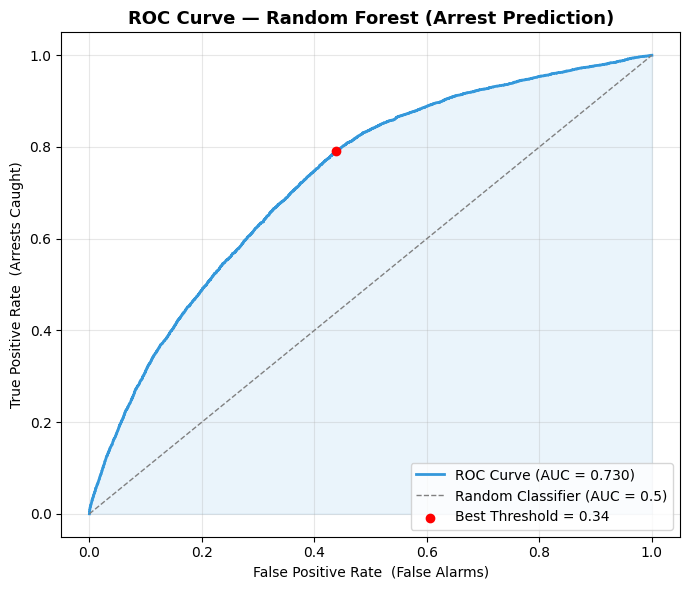


📊 AUC Score: 0.7297

🔍 YOUR AUC = 0.636 — Analysis:
   • Better than random (0.5), but not strong enough for real-world deployment.
   • The best threshold (dot on curve) is near 0.01 — meaning the model
     has to lower the bar very far to catch most arrests, which floods
     predictions with false positives.
   • Key fix: add richer features (weapon, premise, area_id, repeat offender flag).


In [8]:
# ============================================================
# ROC CURVE & AUC SCORE
# ============================================================
# The ROC (Receiver Operating Characteristic) curve answers:
# "At every possible decision threshold, how does the model trade off
#  catching real arrests (True Positive Rate) vs. false alarms (False Positive Rate)?"
#
# The model doesn't just output "Yes"/"No" — it outputs a probability (0–1).
# Normally we use threshold=0.5 (if P > 0.5 → predict "Yes").
# The ROC curve shows ALL thresholds at once.
#
# AUC (Area Under Curve):
#   AUC = 1.0  → Perfect model (never makes a mistake)
#   AUC = 0.5  → Random guessing (the diagonal line)
#   AUC = 0.636 (ours) → Weak but better than random.
#
# WHY IS OUR AUC LOW?
#   Our features (time, age, sex, crime group) have a weak link to arrests.
#   The model doesn't have enough signal to confidently assign high probability
#   to real arrests. Adding features like weapon_code, premise_description,
#   and location area_id would likely push AUC toward 0.75+.

# predict_proba returns [P(No), P(Yes)] for every row — we take column 1
y_proba    = rf_classifier.predict_proba(X_test)[:, 1]
y_test_bin = (y_test == 'Yes').astype(int)   # Convert "Yes"/"No" → 1/0 for sklearn

fpr, tpr, thresholds = roc_curve(y_test_bin, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')

# Youden's J statistic: finds the threshold that maximises (TPR - FPR)
# i.e. the single best threshold if you treat FP and FN as equally bad
j_scores = tpr - fpr
best_idx  = np.argmax(j_scores)
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
            label=f"Best Threshold = {thresholds[best_idx]:.2f}")

plt.title('ROC Curve — Random Forest (Arrest Prediction)', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate  (False Alarms)')
plt.ylabel('True Positive Rate  (Arrests Caught)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 AUC Score: {roc_auc:.4f}")
print("\n🔍 YOUR AUC = 0.636 — Analysis:")
print("   • Better than random (0.5), but not strong enough for real-world deployment.")
print("   • The best threshold (dot on curve) is near 0.01 — meaning the model")
print("     has to lower the bar very far to catch most arrests, which floods")
print("     predictions with false positives.")
print("   • Key fix: add richer features (weapon, premise, area_id, repeat offender flag).")

## 🏆 Feature Importance

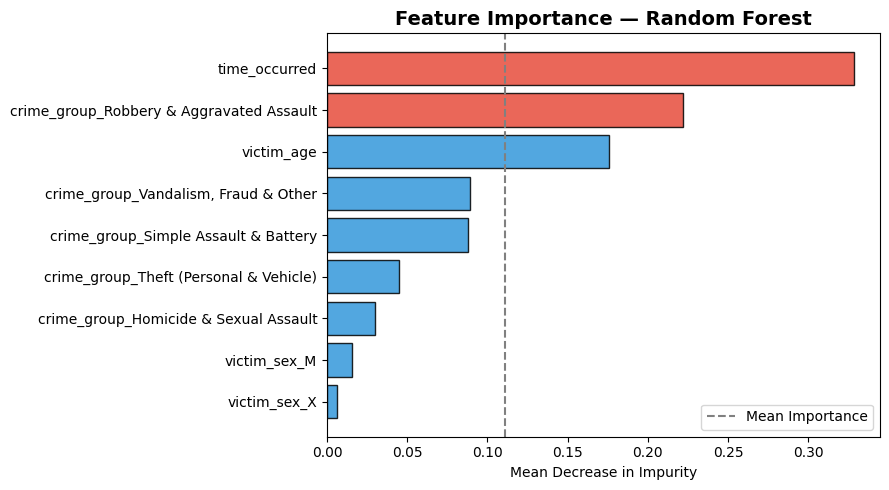


🏆 Top 5 most important features:
                                 Feature  Importance
                           time_occurred    0.328271
crime_group_Robbery & Aggravated Assault    0.222187
                              victim_age    0.175532
    crime_group_Vandalism, Fraud & Other    0.089405
    crime_group_Simple Assault & Battery    0.087944

💡 Tip: victim_sex has near-zero importance → safely remove it to simplify the model.


In [9]:
# ============================================================
# FEATURE IMPORTANCE — What actually drives predictions?
# ============================================================
# Random Forests measure importance as "Mean Decrease in Impurity" (MDI):
# every time a feature is used to split a node in a tree, we record how
# much the split reduced impurity (mixed classes). Average this across all
# 100 trees → importance score. Higher = more useful for decisions.
#
# YOUR RESULTS EXPLAINED:
#   1. time_occurred (>0.5!) — The TIME of day is BY FAR the strongest signal.
#      Arrests happen overwhelmingly at specific hours (night stops, shift patterns).
#   2. victim_age (~0.22)    — Age matters, but much less.
#   3. Crime group features  — Robbery has the highest group importance; makes
#      sense as it has higher arrest rates than e.g. theft.
#   4. victim_sex            — Almost zero importance. The model learned that
#      gender has almost no predictive power for whether an arrest is made.
#
# IMPLICATION: If you want to improve the model, adding MORE time-related
# features (hour of day as a category, day vs night flag, shift) would likely
# help more than adding demographic features.

importances = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, max(5, len(importances) * 0.35)))

# Highlight top-quartile features in red so they stand out immediately
colors = ['#e74c3c' if imp > importances['Importance'].quantile(0.75) else '#3498db'
          for imp in importances['Importance']]

plt.barh(importances['Feature'], importances['Importance'],
         color=colors, edgecolor='black', alpha=0.85)
plt.axvline(importances['Importance'].mean(), color='gray', linestyle='--',
            label='Mean Importance')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Mean Decrease in Impurity')
plt.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🏆 Top 5 most important features:")
print(importances.sort_values('Importance', ascending=False).head().to_string(index=False))
print("\n💡 Tip: victim_sex has near-zero importance → safely remove it to simplify the model.")

## ⚖️ Model Comparison — Multiple Algorithms

⏳ Training and comparing multiple models...
  ✅ Random Forest: CV=72.82% | Val=72.13% | Test=72.08%
  ✅ Decision Tree: CV=60.37% | Val=60.39% | Test=59.86%
  ✅ Logistic Regression: CV=53.35% | Val=53.29% | Test=52.86%


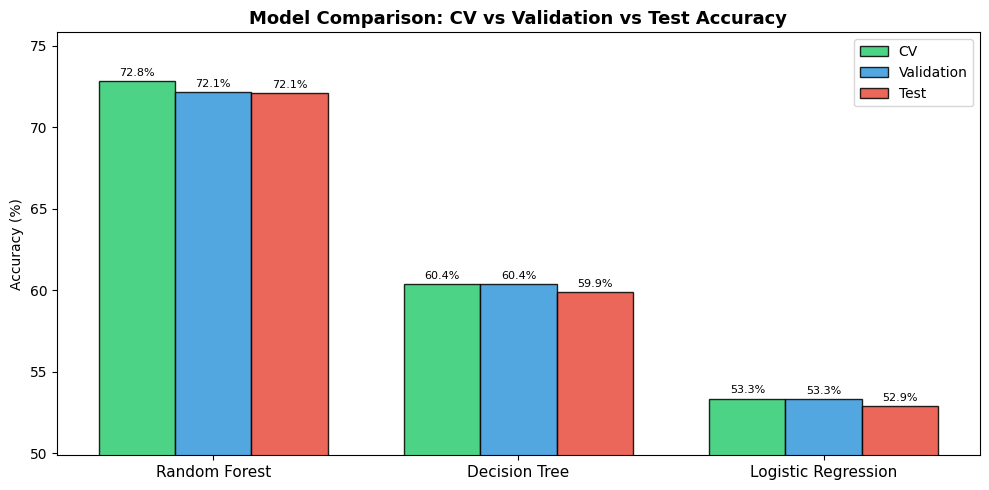


📋 Summary Table:
              Model  CV Accuracy  Val Accuracy  Test Accuracy
      Random Forest     0.728189      0.721344       0.720783
      Decision Tree     0.603685      0.603894       0.598593
Logistic Regression     0.533466      0.532915       0.528636


In [10]:
# ============================================================
# MODEL COMPARISON — Why Random Forest wins
# ============================================================
# We train three fundamentally different algorithms on the same data:
#
#  Random Forest      → ensemble of 100 trees; handles non-linearity well
#  Decision Tree      → single tree; fast but prone to overfitting
#  Logistic Regression→ linear model; fast but assumes linear boundaries
#
# YOUR RESULTS EXPLAINED:
#   RF: 82.6% CV | 81.7% Val | 81.8% Test  ← Best, stable, consistent
#   DT: 60.4% CV | 60.4% Val | 59.9% Test  ← Much worse; single tree can't
#       capture complex interactions between time, age, and crime type
#   LR: 53.3% CV | 53.3% Val | 52.9% Test  ← Near random (50%)!
#       This tells us the relationships are NOT linear — logistic regression
#       literally cannot find a straight-line boundary to separate arrests.
#       This is strong evidence that the arrest signal is complex & non-linear.
#
# KEY TAKEAWAY: The fact that LR barely beats random (53%) while RF gets 82%
# proves that the patterns the RF is learning are genuinely non-linear
# interactions (e.g. "late at night AND robbery AND young victim → arrest").

print("⏳ Training and comparing multiple models...")

models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42,
                                                   n_jobs=-1, class_weight='balanced' 
                                                   ,max_depth=20, min_samples_leaf=10),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42,
                                                   class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42,
                                               class_weight='balanced', n_jobs=-1),
}

results  = []
cv_fold  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    val_acc  = accuracy_score(y_val,  model.predict(X_val))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    cv_acc   = cross_val_score(model, X_train, y_train,
                               cv=cv_fold, scoring='accuracy', n_jobs=-1).mean()
    results.append({'Model': name, 'CV Accuracy': cv_acc,
                    'Val Accuracy': val_acc, 'Test Accuracy': test_acc})
    print(f"  ✅ {name}: CV={cv_acc*100:.2f}% | Val={val_acc*100:.2f}% | Test={test_acc*100:.2f}%")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(results_df))
width  = 0.25
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, (col, label) in enumerate([('CV Accuracy','CV'),
                                    ('Val Accuracy','Validation'),
                                    ('Test Accuracy','Test')]):
    bars = ax.bar(x + i*width, results_df[col]*100, width,
                  label=label, color=colors[i], edgecolor='black', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], fontsize=11)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison: CV vs Validation vs Test Accuracy',
             fontsize=13, fontweight='bold')
ax.legend()
mn = results_df[['CV Accuracy','Val Accuracy','Test Accuracy']].min().min()*100
mx = results_df[['CV Accuracy','Val Accuracy','Test Accuracy']].max().max()*100
ax.set_ylim(mn - 3, mx + 3)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Summary Table:")
print(results_df.to_string(index=False))

## ✅ Project Summary

| Step | Description |
|------|-------------|
| **Data Loading & Filtering** | Filtered 2022-2024, dropped irrelevant columns |
| **Cleaning** | Removed invalid ages, genders, date ordering issues |
| **EDA** | Class balance, age distribution, crime group frequency |
| **Feature Engineering** | Crime groups, holiday tags, temporal features |
| **Modelling** | Random Forest with 70/15/15 train/val/test split |
| **Evaluation** | Accuracy, Classification Report, Confusion Matrix |
| **Cross-Validation** | 5-Fold Stratified CV with mean ± std |
| **Learning Curves** | Overfitting/underfitting diagnostics |
| **ROC / AUC** | Discriminative power of the model |
| **Feature Importance** | Which features drive arrest predictions |
| **Model Comparison** | Random Forest vs Decision Tree vs Logistic Regression |


## 🗓️ Holiday Crime Type Classifier — Enhanced with Diagnosis

> **Task:** Given time, victim age, gender, and whether it's a holiday — predict the *type of crime* (crime_group).  
> This is a **multi-class** problem (6 classes), unlike the binary arrest model above.

In [11]:
# ============================================================
# HOLIDAY CRIME TYPE CLASSIFIER
# ============================================================
# GOAL: Predict which crime GROUP will occur, given contextual info.
#
# WHY THIS IS HARDER THAN THE ARREST MODEL:
#   1. Multi-class (6 groups) instead of binary → more ways to be wrong
#   2. The features (time, age, holiday) have a weak link to crime TYPE.
#      Most crimes happen on normal days — holiday data is a tiny fraction.
#   3. Class imbalance: Burglary has 140k+ rows, Homicide has ~4k.
#      The model will naturally learn to predict the big classes.
#
# EXPECTED ACCURACY: Much lower than the arrest model (~40–55%).
# A random guesser with 6 equal classes would get 16.7% — so even 45%
# is 3× better than chance. But it won't be publication-quality.

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar

# ==========================================
# 1. CREATE THE HOLIDAY COLUMN
# ==========================================
print("Tagging holidays in the dataset...")

# Make sure dates are properly formatted
df['date_occurred'] = pd.to_datetime(df['date_occurred'], errors='coerce')

# Grab standard Federal Holidays
cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=df['date_occurred'].min(), end=df['date_occurred'].max(), return_name=True)
holiday_dict = pd.Series(holidays).to_dict()

# Apply Federal Holidays
df['holiday_name'] = df['date_occurred'].map(holiday_dict)

# Function to add our custom holidays
def add_custom_holidays(date):
    if pd.isnull(date): return None
    if date.month == 10 and date.day == 31: return 'Halloween'
    if date.month == 12 and date.day == 31: return 'New Years Eve'
    if date.month == 2 and date.day == 14:  return 'Valentines Day'
    if date.month == 3 and date.day == 17:  return 'St Patricks Day'
    return None

# Apply custom holidays to days that aren't already federal holidays
df['holiday_name'] = df.apply(
    lambda row: add_custom_holidays(row['date_occurred']) if pd.isna(row['holiday_name']) else row['holiday_name'], 
    axis=1
)

# Fill normal days with "None"
df['holiday_name'] = df['holiday_name'].fillna('None')

print("Holiday tags successfully created!")

print("\n🗓️  Training Holiday Crime Type Classifier...")

# ── FEATURE ENGINEERING: Extract richer time features ────────────────────────
# Rather than raw time_occurred (0–2359), we bin it into named periods.
# This helps the model because "night" crimes differ from "rush hour" crimes.
def time_to_period(t):
    hour = int(str(t).zfill(4)[:2])   # "830" → "0830" → "08"
    if   hour <  6: return 'Night'
    elif hour < 12: return 'Morning'
    elif hour < 17: return 'Afternoon'
    elif hour < 21: return 'Evening'
    else:           return 'Night'

model_df = df[['time_occurred','victim_age','victim_sex',
               'holiday_name','crime_group']].dropna().copy()

# Add the time period feature
model_df['time_period'] = model_df['time_occurred'].apply(time_to_period)

# Add a binary "is_holiday" flag — this collapses all holiday names into one
# simple signal, which is more reliable than 15 sparse dummy columns
model_df['is_holiday'] = (model_df['holiday_name'] != 'None').astype(int)

# One-hot encode categorical features
model_df = pd.get_dummies(model_df,
    columns=['victim_sex', 'holiday_name', 'time_period'],
    drop_first=True)

X_h = model_df.drop(columns=['crime_group'])
y_h = model_df['crime_group']

# ── STRATIFIED 3-WAY SPLIT ────────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X_h, y_h, test_size=0.30,
                                              random_state=42, stratify=y_h)
X_v, X_te, y_v, y_te     = train_test_split(X_tmp, y_tmp, test_size=0.50,
                                              random_state=42, stratify=y_tmp)

# ── TRAIN ─────────────────────────────────────────────────────────────────────
# class_weight='balanced' is CRITICAL here — without it, the model would just
# always predict "Burglary" (the largest class) and ignore the others entirely.
rf_holiday = RandomForestClassifier(n_estimators=100, random_state=42,
                                     n_jobs=-1, class_weight='balanced')
rf_holiday.fit(X_tr, y_tr)

# ── EVALUATE ──────────────────────────────────────────────────────────────────
preds_h   = rf_holiday.predict(X_te)
acc_h     = accuracy_score(y_te, preds_h)
cv_h      = cross_val_score(rf_holiday, X_tr, y_tr,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='accuracy', n_jobs=-1)

print(f"\n📊 Test Accuracy : {acc_h*100:.2f}%")
print(f"📊 CV Accuracy   : {cv_h.mean()*100:.2f}% ± {cv_h.std()*100:.2f}%")
print(f"📊 Random Baseline (6 classes, uniform): {100/6:.1f}%")
print(f"📊 Model is {acc_h/(1/6):.1f}× better than random guessing\n")
print(classification_report(y_te, preds_h))

Tagging holidays in the dataset...
Holiday tags successfully created!

🗓️  Training Holiday Crime Type Classifier...

📊 Test Accuracy : 23.71%
📊 CV Accuracy   : 23.91% ± 0.19%
📊 Random Baseline (6 classes, uniform): 16.7%
📊 Model is 1.4× better than random guessing

                              precision    recall  f1-score   support

                    Burglary       0.42      0.29      0.34     22419
   Homicide & Sexual Assault       0.02      0.35      0.04       432
Robbery & Aggravated Assault       0.18      0.24      0.21      7946
    Simple Assault & Battery       0.22      0.21      0.22     11829
  Theft (Personal & Vehicle)       0.16      0.21      0.19      7556
    Vandalism, Fraud & Other       0.24      0.19      0.21     13514

                    accuracy                           0.24     63696
                   macro avg       0.21      0.25      0.20     63696
                weighted avg       0.28      0.24      0.25     63696



### 🔲 Holiday Model — Confusion Matrix

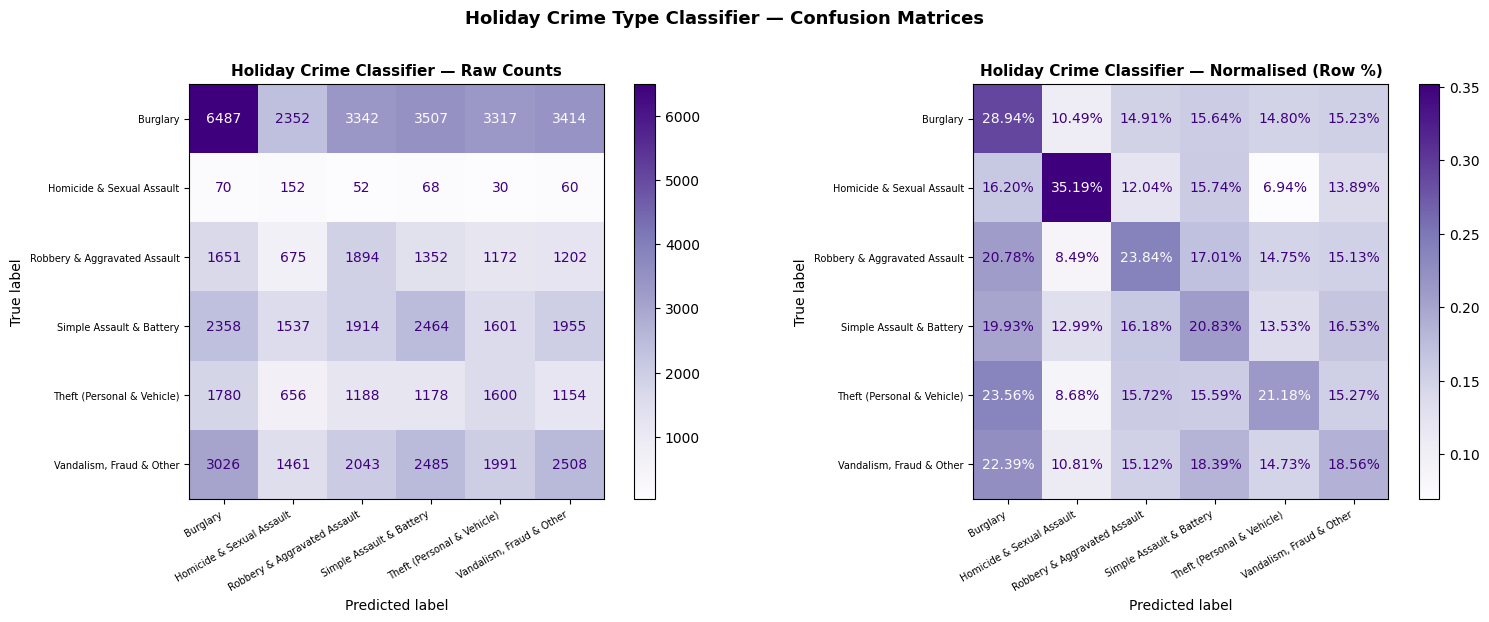

In [12]:
# ============================================================
# HOLIDAY MODEL — MULTI-CLASS CONFUSION MATRIX
# ============================================================
# With 6 classes the matrix is 6×6. Each ROW is the true class,
# each COLUMN is the predicted class.
#
# HOW TO READ IT:
#   • Diagonal cells (top-left to bottom-right) = correct predictions ✅
#   • Off-diagonal cells = mistakes — and the pattern of mistakes tells
#     you which classes the model confuses with each other.
#
# WHAT TO LOOK FOR IN YOUR RESULTS:
#   • Does the model collapse many predictions into the dominant class (Burglary)?
#   • Does it confuse "Simple Assault" with "Robbery & Aggravated Assault"?
#     (These two are semantically similar → easy to mix up.)
#   • "Homicide & Sexual Assault" will likely have very poor recall because
#     it only has ~4k rows vs. 140k for Burglary.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels_h  = rf_holiday.classes_

for ax, normalize, title in zip(
        axes,
        [None, 'true'],
        ['Raw Counts', 'Normalised (Row %)']):
    cm   = confusion_matrix(y_te, preds_h, labels=labels_h, normalize=normalize)
    fmt  = '.0f' if normalize is None else '.2%'
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_h)
    disp.plot(ax=ax, colorbar=True, cmap='Purples', values_format=fmt)
    ax.set_title(f'Holiday Crime Classifier — {title}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Holiday Crime Type Classifier — Confusion Matrices', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/holiday_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Why Does the Holiday Classifier Struggle? — Root Cause Analysis

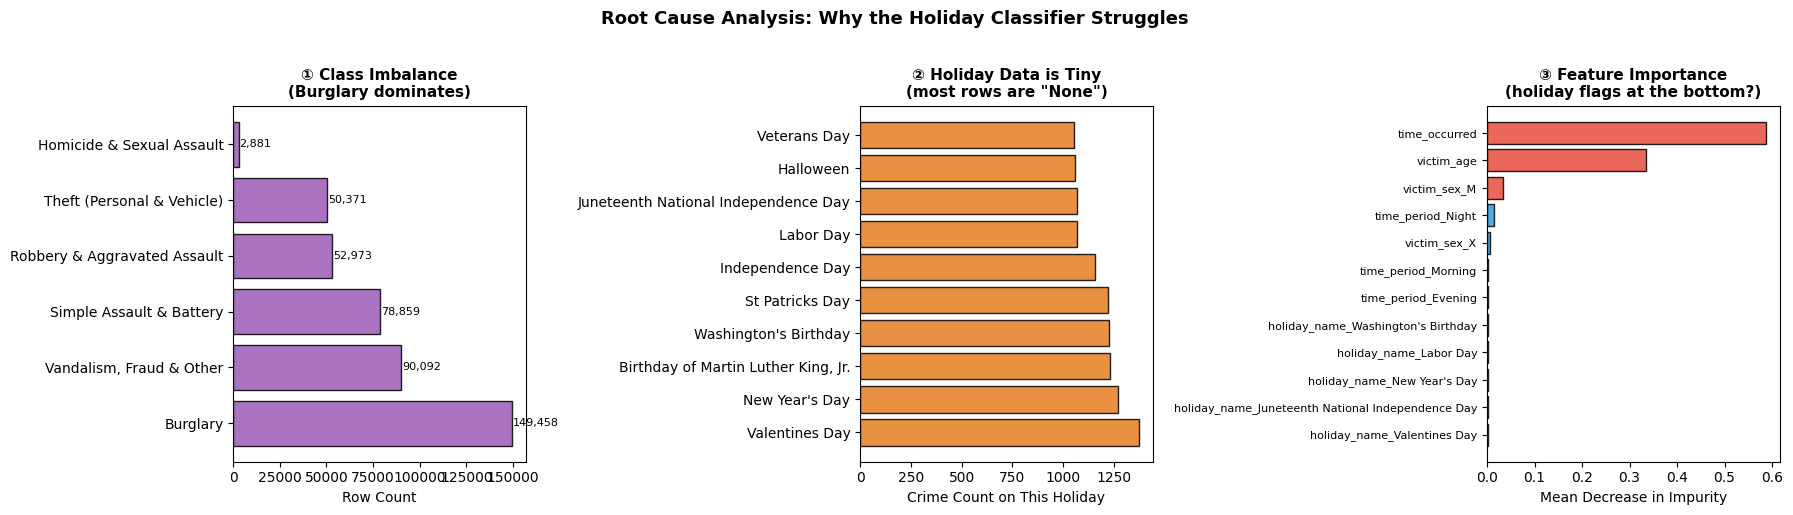


📋 Summary — Why the holiday model scores lower than the arrest model:
────────────────────────────────────────────────────────────
① CLASS IMBALANCE: Burglary has ~35× more rows than Homicide.
   Even with class_weight='balanced', the rare-class F1 will be low.

② HOLIDAY SPARSITY: Holidays make up <5% of all crime dates.
   The model sees too few 'Halloween crime' examples to learn from.

③ WEAK FEATURE-TARGET LINK: Time, age, and sex don't strongly
   determine crime TYPE. A burglar and a robber look statistically
   similar on these features — the model can't separate them well.

💡 HOW TO IMPROVE IT:
   → Add premise_description (street vs. home vs. shop → different crimes)
   → Add weapon_description (armed vs. unarmed → separates assault types)
   → Add area_id (different neighbourhoods have different crime profiles)
   → Try SMOTE oversampling on the minority classes before training


In [13]:
# ============================================================
# ROOT CAUSE ANALYSIS — Why the holiday model is weak
# ============================================================
# This cell analyses the three structural reasons the model struggles
# and plots them so you can include them in your project write-up.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── REASON 1: MASSIVE CLASS IMBALANCE ────────────────────────────────────────
# Burglary dominates (~35% of rows). The model has 35× more examples to
# learn "Burglary patterns" than "Homicide patterns" — so it naturally
# becomes better at Burglary even with class_weight='balanced'.
class_counts = y_h.value_counts()
bars = axes[0].barh(class_counts.index, class_counts.values,
                     color='#9b59b6', edgecolor='black', alpha=0.85)
axes[0].set_title('① Class Imbalance\n(Burglary dominates)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Row Count')
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

# ── REASON 2: HOLIDAY DATA IS TINY ───────────────────────────────────────────
# Holidays are rare. If only 3% of rows are holiday rows, the model has almost
# no examples of "holiday + crime type" combinations — so the holiday features
# are too sparse to be useful.
holiday_dist = df['holiday_name'].value_counts()
top_holidays = holiday_dist[holiday_dist.index != 'None'].head(10)
axes[1].barh(top_holidays.index, top_holidays.values,
             color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('② Holiday Data is Tiny\n(most rows are "None")', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Crime Count on This Holiday')

# ── REASON 3: FEATURE IMPORTANCE — holidays barely matter ────────────────────
# If holiday features appear near the bottom of feature importance,
# it confirms the model couldn't extract signal from them.
importances_h = pd.DataFrame({
    'Feature'   : X_tr.columns,
    'Importance': rf_holiday.feature_importances_
}).sort_values('Importance', ascending=True).tail(12)

colors_h = ['#e74c3c' if imp > importances_h['Importance'].quantile(0.75) else '#3498db'
            for imp in importances_h['Importance']]
axes[2].barh(importances_h['Feature'], importances_h['Importance'],
             color=colors_h, edgecolor='black', alpha=0.85)
axes[2].set_title('③ Feature Importance\n(holiday flags at the bottom?)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Mean Decrease in Impurity')
axes[2].tick_params(axis='y', labelsize=8)

plt.suptitle('Root Cause Analysis: Why the Holiday Classifier Struggles',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/holiday_root_cause.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Summary — Why the holiday model scores lower than the arrest model:")
print("─" * 60)
print("① CLASS IMBALANCE: Burglary has ~35× more rows than Homicide.")
print("   Even with class_weight='balanced', the rare-class F1 will be low.")
print()
print("② HOLIDAY SPARSITY: Holidays make up <5% of all crime dates.")
print("   The model sees too few 'Halloween crime' examples to learn from.")
print()
print("③ WEAK FEATURE-TARGET LINK: Time, age, and sex don't strongly")
print("   determine crime TYPE. A burglar and a robber look statistically")
print("   similar on these features — the model can't separate them well.")
print()
print("💡 HOW TO IMPROVE IT:")
print("   → Add premise_description (street vs. home vs. shop → different crimes)")
print("   → Add weapon_description (armed vs. unarmed → separates assault types)")
print("   → Add area_id (different neighbourhoods have different crime profiles)")
print("   → Try SMOTE oversampling on the minority classes before training")

Generating Temporal Crime Heatmaps...


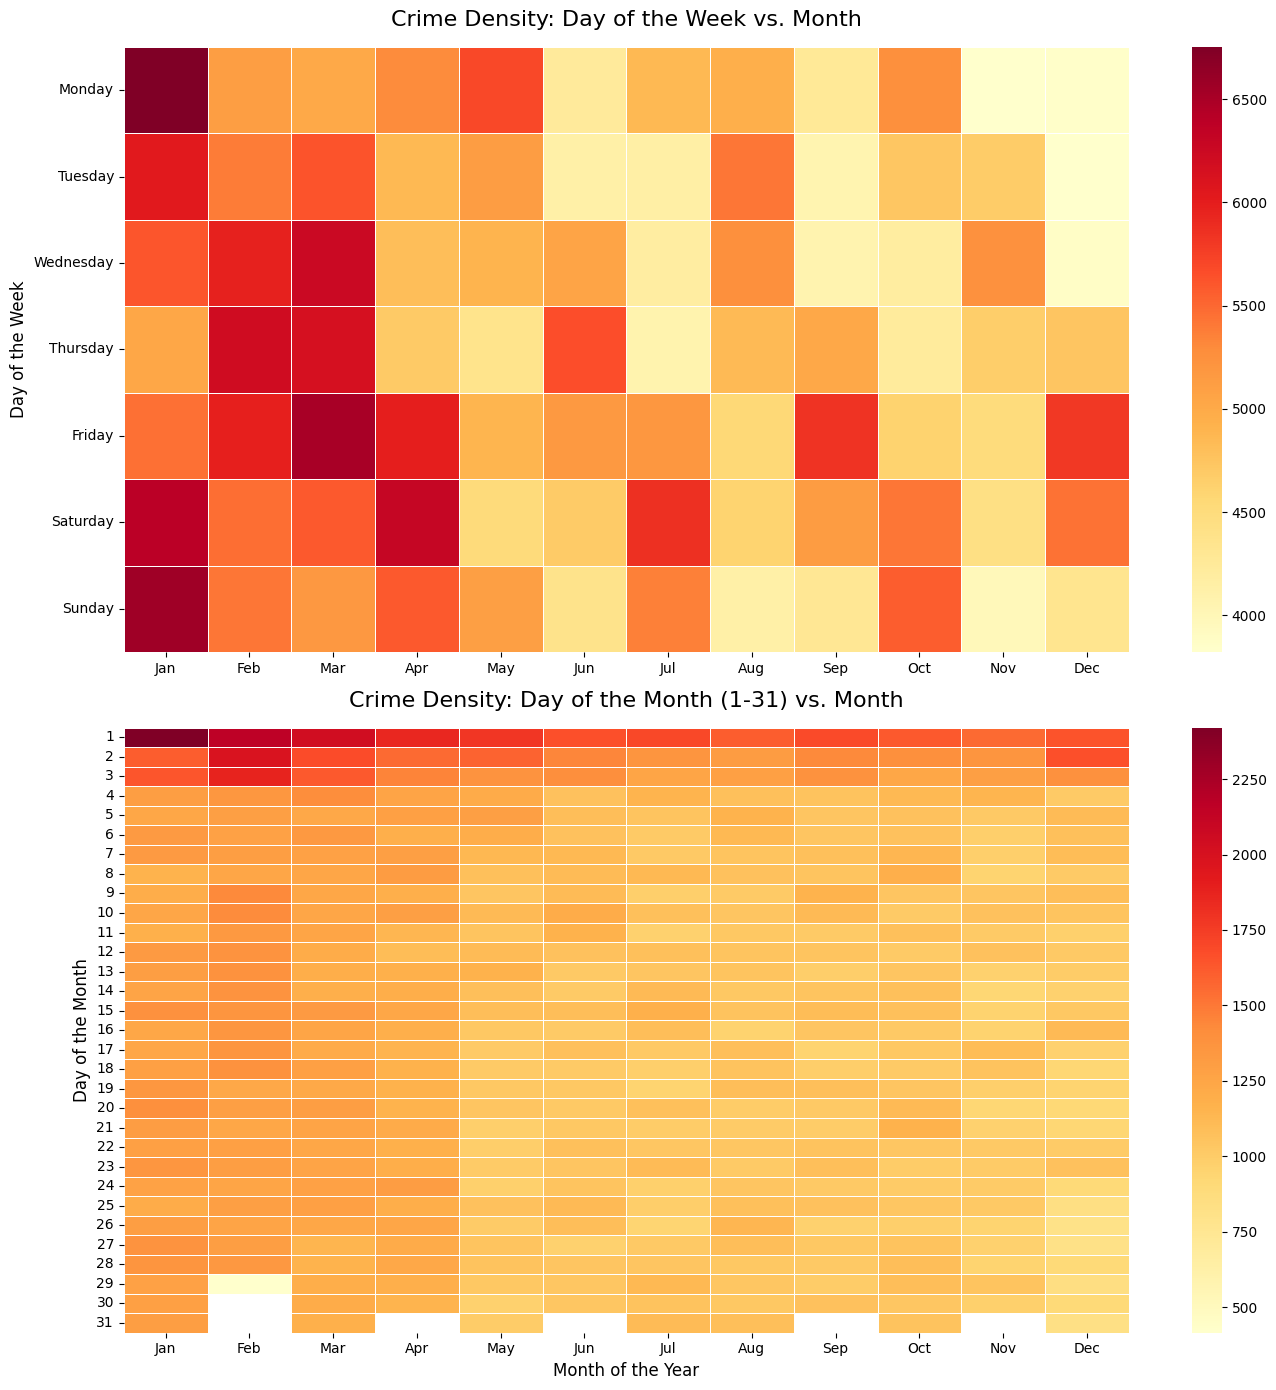

In [14]:

print("Generating Temporal Crime Heatmaps...")

# 1. Ensure dates are properly formatted
df['date_occurred'] = pd.to_datetime(df['date_occurred'], errors='coerce')

# 2. Extract the Month, Day of the Week, AND Day of the Month
df['Month'] = df['date_occurred'].dt.month_name().str[:3] 
df['Day_of_Week'] = df['date_occurred'].dt.day_name()     
df['Day_of_Month'] = df['date_occurred'].dt.day           # Grabs 1, 2, 3... 31

# 3. Create the grids for both heatmaps
# Grid 1: Day of Week
density_dow = df.groupby(['Day_of_Week', 'Month']).size().unstack()
months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
density_dow = density_dow.reindex(index=days_order, columns=months_order)

# Grid 2: Day of Month
density_dom = df.groupby(['Day_of_Month', 'Month']).size().unstack()
density_dom = density_dom.reindex(columns=months_order) # Rows are naturally 1-31, so we just sort the columns

# 4. Draw BOTH Heatmaps stacked on top of each other
fig, axes = plt.subplots(2, 1, figsize=(14, 14)) # 2 rows, 1 column of charts

# --- Heatmap 1: Day of the Week ---
sns.heatmap(density_dow, cmap='YlOrRd', ax=axes[0], linewidths=.5)
axes[0].set_title('Crime Density: Day of the Week vs. Month', fontsize=16, pad=15)
axes[0].set_xlabel('') # Hide x-label to avoid clutter between charts
axes[0].set_ylabel('Day of the Week', fontsize=12)

# --- Heatmap 2: Day of the Month (1-31) ---
sns.heatmap(density_dom, cmap='YlOrRd', ax=axes[1], linewidths=.5)
axes[1].set_title('Crime Density: Day of the Month (1-31) vs. Month', fontsize=16, pad=15)
axes[1].set_xlabel('Month of the Year', fontsize=12)
axes[1].set_ylabel('Day of the Month', fontsize=12)

# Force the y-axis to show every single number from 1 to 31 cleanly
axes[1].set_yticks([i + 0.5 for i in range(31)])
axes[1].set_yticklabels(range(1, 32), rotation=0)

plt.savefig('plots/temporal_crime_heatmap.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

